### Source Detection Module(2nd in operation order):

Description: Applies an existing list of sources (from every observation of M87) to the
input files; converting each source’s celestial coordinates (RA/DEC) to pixel coordinates (X/Y)
on the input image. If using this code for other galaxies, a list of sources will need to be made for each individual galaxy.


### Expected Results:
Input event file ending in “evt2.fits" displayed in js9

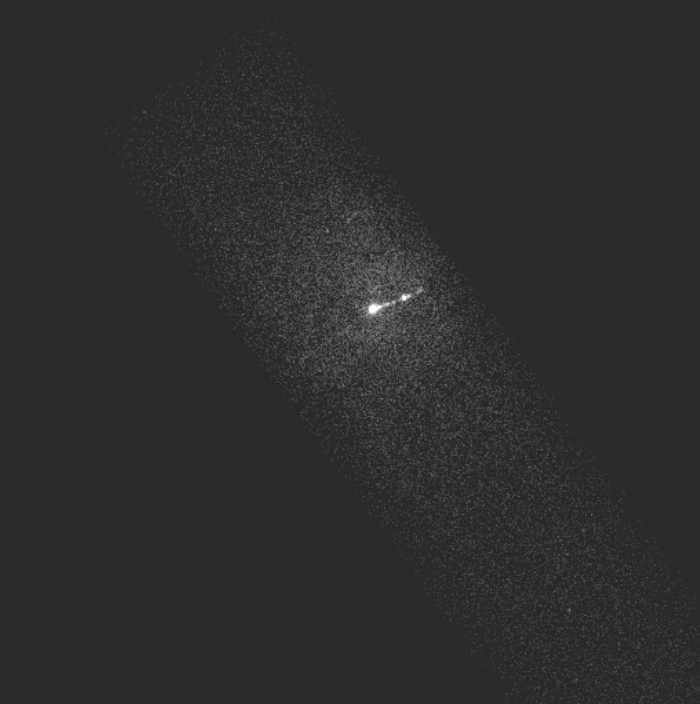

Input event file with all potential M87 sources highlighted displayed in js9

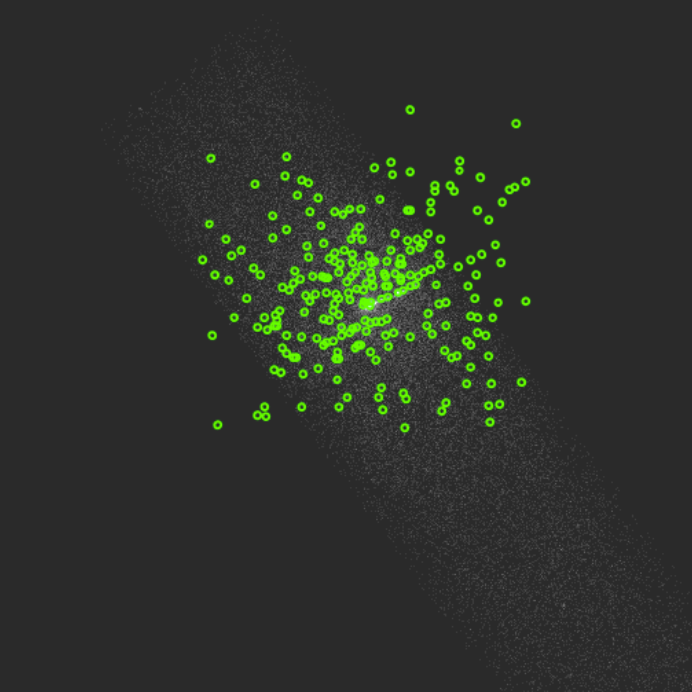

### Code for M87 Data:

(VERY IMPORTANT) NOTE: This code only works if there is already a full list of sources made prior to running any modules; otherwise this section of the code will not work for galaxies other than M87.

A list of sources can be made using JS9/DS9, and used in place of the M87 list, and then used with this new code.

Alternatively, if working with another galaxy, use the older detection code at the bottom of this notebook.

This older code will search for sources using data in the input observation folder, but it has not been tested with data from other galaxies so use it with caution.

In [ ]:
#This module does the following:
#Uses variables from the Input Module.
#Assumes the input folder is formatted EXACTLY like those downloaded from the Chandra Data Archive.
#Using the original "M87_sources_celestial_coord.reg" file to create a physical coordinate region file, "sources.reg", for later use in other modules. This region file (should) only contain sources in the bounds of the event image (no sources in the blank space outside of the image).
#Creates a copy of the original event file for use in the Visualization module.
#Places all newly created files in the user-specified "outputDataFolderPath"

#Import modules:

from ciao_contrib import runtool as rt
from subprocess import *
import os
from pathlib import Path
from os import listdir
from os.path import isfile, join
from lightcurves import *
from paramio import *
import paramio
from pycrates import read_file

#This is a bandaid fix needed to clear any previous plots and fix some issues with matplotlib. Remove if matplotlib isn’t causing any issues.
%matplotlib inline 
import matplotlib.pyplot as plt
plt.clf()

from sherpa.astro.ui import *
from sherpa_contrib.notebook_plotter import notebook_plotter

#This bandaid fix is used to suppress a warning from astropy whenever opening a .fits file. 
import warnings
from astropy.io.fits.verify import VerifyWarning
warnings.simplefilter('ignore', category=VerifyWarning)

#Define functions:

#None

#Set variables:

#The location of the folder named "primary" within the input folder:
inputPrimaryDataFolderPath = inputDataFolderPath+"/primary/"
#This folder should always contain the "evt2.fits" file used later.

#This variable will be replaced with the event file used for source detection.
inputEventFile = ""

#Boolean/Constants used for a later script, defined here for convenience.
eventFileFound = False
FILE_END_STRING = "evt2"
FITS_FILE_EXTENSION = ".fits"

#Variables used for making a list of sources later.
regionList = []
regionString = ""

#Getting the name and path of each file in "primary" folder:
#NOTE: This will ignore any folders within the "primary" folder, which is alright because it doesn't have any.

fileNamesList = [file for file in listdir(inputPrimaryDataFolderPath) if isfile(join(inputPrimaryDataFolderPath, file))]
filePathsList = [inputPrimaryDataFolderPath+fileName for fileName in fileNamesList]

print("Listing files in primary folder of", inputDataFolderPath, ":\n")
    
for fileName in fileNamesList: #This filename listing loop is not needed, and can be removed to make the output less cluttered.
    print(fileName) 

#Finding the event, or "evt2.fits" file within the "primary" folder:

#Looking for "evt2" AND ".fits" in filenames:
for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        inputEventFile = file
        eventFileFound = True
        
        print("Event file located at:", inputEventFile)
        break

#NOTE: This error handling code will fail to occur if the flag "eventFileFound" is not reset before running this part of the code.

if eventFileFound == False:
    print("\nInput primary folder", inputPrimaryDataFolderPath, "\ndoes not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")
    raise SystemExit("Input primary folder", inputPrimaryDataFolderPath, "does not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")

#Make a copy of the event file and place it in the output folder; allows the Visualization Module easy access to the event file without needing the grab it from the original observation folder:

dmCopyInfile = inputEventFile
dmCopyOutfile = outputDataFolderPath+"/copy_evt2.fits"

call(["dmcopy", dmCopyInfile, dmCopyOutfile])

#Convert input region file from celestial to physical coordinates:

makeRegRegion="region("+M87sourceFileLocation+")"
makeRegOutfile = outputDataFolderPath+"/sources.reg"
makeRegWcsfile = inputEventFile

call(["punlearn", "dmmakereg"])
pset ("dmmakereg", "outfile", makeRegOutfile)
pset ("dmmakereg", "append", "no")
pset ("dmmakereg", "kernel", "ascii")
pset ("dmmakereg", "wcsfile", makeRegWcsfile)
pset ("dmmakereg", "clobber", "yes")

call(["dmmakereg", makeRegRegion])

physicalRegFileLocation = makeRegOutfile

print("\nPhysical coordinates region file placed in:", outputDataFolderPath, "\n")

#Make a list of regions from the output region file:
#NOTE: Each of the regions in this list represents a potential source.

with open(physicalRegFileLocation, "r", encoding="utf-8") as file:
    content = file.read()

#This script, which reads the physical region file, needs to skip over the text included at the beginning of the region file. To do this, the code will wait until the string "cal" appears, as "c", "a", and "l" are the last three characters in the word "physical", and physical is the last word that appears at the end of this starting string, which we want to skip over. When reaching this end of the starting string, the code that checks for region syntax will begin to function and read the list of regions from the region file.

currentChar = "None"
previousChar = "None"
previousPreviousChar = "None"
readingRegions = 0

for i in content:

    if readingRegions == 1:
        if i == "\n" or i == " " or i == "#":
            pass
        else:
            regionString = regionString+i

        if i == ")":
            #print(regionString)
            regionList.append(regionString)
            regionString = ""
    else:
        previousPreviousChar = previousChar
        previousChar = currentChar
        currentChar = i
        if currentChar == "l" and previousChar == "a" and previousPreviousChar == "c":
            readingRegions = 1

#Remove any source regions(from the variable "regionList"(used in other modules), not the actual "sources.reg" file) with an area of zero, OR with zero counts; this is to prevent errors in future modules.

print("\nRemoving invalid regions(<1 min)") #Time estimate is only valid for event/evt2 files around 4mb or so. Otherwise this loop can take several minutes to complete for larger event files.

i = 1
regionsRemoved = 0
while i <= len(regionList):
    
    currentRegion = regionList[i-1]

    #Check if the region has a radius of zero; this could accidentally flag other strings that have another value (not the radius) that happens to also be exactly zero, but the odds of this happening are low. This code should be removed or replaced as it WILL flag and remove otherwise valid sources in large enough source lists.
    if ",0.000000" in currentRegion:
        print("Source region (", i+regionsRemoved, ") has a radius of zero, removing from regionList")
        regionList.pop(i-1)
        regionsRemoved+=1
        i-=1

    #Checking if each source has a count value above zero (i.e. the region isn't outside the image):

    dmExtractOutfile = outputDataFolderPath+"/count_check.fits"
    dmExtractInfile = inputEventFile+"[bin sky="+currentRegion+"]"

    call(["punlearn", "dmextract"])
    pset ("dmextract", "opt", "generic")
    pset ("dmextract", "clobber", "yes")

    call(["dmextract", dmExtractInfile, dmExtractOutfile])

    HDUList = fits.open(dmExtractOutfile) #Open .fits file, save data as an HDUList object,
    data = HDUList[1].data #Index 1 is where counts info is,
    HDUList.close() #Close the HDUList.

    regionCounts = data[0][15] #This is where the net counts data is.

    if regionCounts == 0:
        print("Source region (", i+regionsRemoved, ") has a net counts of zero, removing from regionList")
        regionList.pop(i-1)
        regionsRemoved+=1
        i-=1

    i+=1

print("\n", len(regionList), "potential sources found:")

for region in regionList:
    print(region)


### Code for Other Galaxies:
(NOTE: This code is an older version of the source detection code, and is untested with the newer modules so it may need to be tweaked to work properly.)

In [ ]:
#This module does the following:
#Uses variables from the Input Module.
#Assumes the input folder is formatted EXACTLY like those downloaded from the Chandra Data Archive.
#Creates a region file "sources.reg" for later use in flare filtering. (NOTE: The Flare Filtering Module is a deprecated module part of an unused data reduction pipeline.)
#Applies the region file "sources.reg" to the original event file to create "bg.fits", which excludes all potential sources from the image.
#Creates several other files from the output of the source detection algorithm wavdetect.
#Places all newly created files in the user-specified "outputDataFolderPath"

#Import modules:

from ciao_contrib import runtool as rt
from subprocess import *

import os
from pathlib import Path
from os import listdir
from os.path import isfile, join

#Define functions:

#None

#Set variables:

#The location of the folder named "primary" within the input folder:
inputPrimaryDataFolderPath = inputDataFolderPath+"/primary/"
#This folder should always contain the "evt2.fits" file used later.

#This variable will be replaced with the event file used for source detection.
inputEventFile = ""

#Boolean/Constants used for a later script.
eventFileFound = False
FILE_END_STRING = "evt2"
FITS_FILE_EXTENSION = ".fits"

#Variables used for making a list of sources later.
regionList = []
regionString = ""

#Getting the name and path of each file in "primary" folder:
#NOTE: This will ignore any folders within the "primary" folder, which is fine because it should have none anyway.

fileNamesList = [file for file in listdir(inputPrimaryDataFolderPath) if isfile(join(inputPrimaryDataFolderPath, file))]
filePathsList = [inputPrimaryDataFolderPath+fileName for fileName in fileNamesList]

print("Listing files in primary folder of", inputDataFolderPath, ":\n")
    
for fileName in fileNamesList:
    print(fileName) 

#Finding the event, or "evt2.fits" file within the "primary" folder:

#Looking for "evt2" AND ".fits" in filenames:
for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        inputEventFile = file
        eventFileFound = True
        
        print("Event file located at:", inputEventFile)
        break

#NOTE: This error handling code will fail to occur if the flag "eventFileFound" is not reset before running this part of the code.

if eventFileFound == False:
    print("\nInput primary folder", inputPrimaryDataFolderPath, "\ndoes not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")
    raise SystemExit("Input primary folder", inputPrimaryDataFolderPath, "does not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")
    
#Calling wavdetect to create a list of sources/a region file, for the input event file:
#NOTE: The parameters for wavdetect are mostly set to their default values, code may need to be tweaked in the future.

#Setting most parameters of wavdetect:
wavdetectInfile = inputEventFile
wavdetectOutfile = outputDataFolderPath+"/out.fits"
wavdetectScellfile = outputDataFolderPath+"/out_scell.fits"
wavdetectImagefile = outputDataFolderPath+"/out_image.fits"
wavdetectDefnbkgfile = outputDataFolderPath+"/out_defnbkg.fits"
wavdetectPsffile = outputDataFolderPath+"/out_psf.fits"
wavdetectRegfile = outputDataFolderPath+"/sources.reg"

call(["punlearn", "wavdetect"])
call(["pset", "wavdetect", wavdetectInfile, wavdetectOutfile, wavdetectScellfile, wavdetectImagefile, wavdetectDefnbkgfile])

#Bandaid fix to set the "regfile" parameter in wavdetect to the name of a variable.
call(["pset", "dmlist", wavdetectRegfile])
call(["pset", "wavdetect", "regfile=)dmlist.infile"])

#Check if wavdetect needs to run or not, because it takes several minutes and doesn't need to run multiple times:

if Path(wavdetectRegfile).exists():
    
    print("Region file already exists, skipping wavdetect")

else:
    
    #NOTE: The wavdetect parameter "sigthresh" should ALWAYS be smaller than 1/(number of pixels in image)
    #"falsesrc" is a different parameter for wavdetect that takes the place of "sigthresh", and it seems to produce less false positives

    print("Running wavdetect to locate potential sources(this might take a few minutes)")
    call(["wavdetect", "clobber=yes", "falsesrc=0.1", "verbose=1"])

    print("\nOutput from wavdetect placed in", outputDataFolderPath, "\n")

#Call dmcopy with the new sources.reg file; this creates "bg.fits", a new event file with the sources removed:
#NOTE: "bg.fits" can be used later for flare filtering.

dmcopyInputFile = inputEventFile+"[exclude sky=region("+wavdetectRegfile+")]"
dmcopyOutputFile = outputDataFolderPath+"/bg.fits"

call(["dmcopy", dmcopyInputFile, dmcopyOutputFile, "clobber=yes"])

print("\nSourceless event file bg.fits placed in", outputDataFolderPath, "\n")

#Make a list of regions from the output region file:
#NOTE: Each of the regions in this list represents a potential source.

with open(wavdetectRegfile, "r", encoding="utf-8") as file:
    content = file.read()

print("Potential Source Regions:\n")

for i in content:
    
    if i == "\n":
        pass
    else:
        regionString = regionString+i

    if i == ")":
        print(regionString)
        regionList.append(regionString)
        regionString = ""

print("\n", len(regionList), "potential sources found.")

#Remove any source regions(from the variable "regionList"(used in other modules), not the actual "sources.reg" file) with an area of zero; this is to prevent errors in future modules.

i = 1
regionsRemoved = 0
while i <= len(regionList):
    
    currentRegion = regionList[i-1]

    #Check if the region has a radius of zero; this could accidentally flag other strings that have another value (not the radius) that happens to be exactly zero, but the odds of this happening seem unlikely.
    if ",0.000000" in currentRegion:
        print("Source region (", i+regionsRemoved, ") has a radius of zero, removing from regionList")
        regionList.pop(i-1)
        regionsRemoved+=1
        i-=1
    i+=1
